In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

wine = load_wine(as_frame=True)
X = wine.data
y = wine.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


1.  Unterteilen Sie die Menge in einen Trainings- und einen Testdatensatz. Der Testdatensatz soll dabei
 20% der Daten beinhalten.

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled , y, test_size=0.2, random_state=42)

2. Führen Sie eine lineare SVM-Regression durch. Verändern Sie den Soft-Margin-Parameter ihres Modells. Können Sie damit das Modell noch verbessern?

In [16]:
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score

svm_model = LinearSVC(C=0.01, random_state=42)
svm_model.fit(X_train, y_train)
svm_model.score(X_train,y_train)

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.9722222222222222


##### Im nächsten Schritt schauen wir uns nur die beiden Merkmale `alcohol` und `proline` an.

3. Führen Sie nun eine SVM-Regression für die beiden genannten Merkmale auf dem gesamten Daten
satz durch. Trennen Sie dazu nun die class_0 von den anderen beiden Klassen.

In [17]:
X_df = pd.DataFrame(X)
X1 = X_df[['alcohol', 'proline']]

y1 = y
y1[y1 != 0] = 1

svm_model = SVC(kernel='linear', C=0.01, random_state=42)
svm_model.fit(X1, y1)
svm_model.score(X1, y1)

0.9269662921348315

4) Plotten Sie die zugehörige Trennungsgerade mit dem besten Score.

c:\Users\Anton\Documents\HfT\S5\02 - Data Science (Gilg)\Programming\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


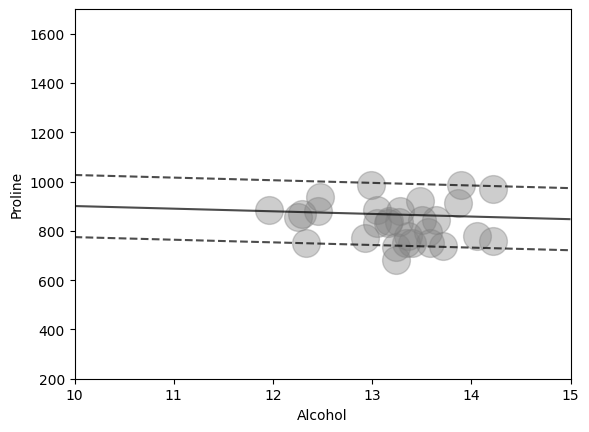

In [30]:
X_plot = X1
y_plot = y1

xlim = [10, 15]      
ylim = [200, 1700]   

#plt.scatter(X[y==1][:,0],X[y==1][:,1], s = 150, marker='o',alpha=0.6, c='r')
#plt.scatter(X[y==0][:,0],X[y==0][:,1], s = 150, marker='o',alpha=0.6, c='b')

plt.scatter(X[y==1].values[:,0], X[y==1].values[:,1], s = 150, marker='o',alpha=0.6, c='r')
plt.scatter(X[y==0].values[:,0], X[y==0].values[:,1], s = 150, marker='o',alpha=0.6, c='b')

plt.xlim(xlim[0],xlim[1])
plt.ylim(ylim[0],ylim[1])

plt.xlabel('Alcohol')
plt.ylabel('Proline')

NBINS = 25
xg = np.linspace(xlim[0], xlim[1], NBINS)
yg = np.linspace(ylim[0], ylim[1], NBINS)
Yg, Xg = np.meshgrid(yg, xg)
xy = np.vstack([Xg.ravel(), Yg.ravel()]).T
P1 = svm_model.decision_function(xy).reshape(Xg.shape)

# Trenngerade und Fehlergrenzen
cont = plt.contour(Xg, Yg, P1, colors='k',
                levels=[-1, 0, 1], alpha=0.7,
                linestyles=['--', '-', '--'])
# Srützvektoren:
plt.scatter(svm_model.support_vectors_[:, 0],svm_model.support_vectors_[:, 1],s=400, facecolors='grey',alpha=0.39)

plt.show()

5. Können Sie die Genauigkeit mit Hilfe eines anderen Kernels verbessern?

In [ ]:
from sklearn.svm import SVC

test_model = SVC(kernel='poly', C=0.01, random_state=42)
test_model.fit(X1, y1)
test_model.score(X1, y1)

0.9213483146067416